# GRADE — full study

**Generalization Robustness Assessment for Detectors in Education**

One notebook, run top to bottom. Sections 1–8 need no GPU and take a few
minutes; section 9 is the training sweep and wants the RTX 3060 Ti;
sections 10+ turn the results into the paper's tables and figures.

| Part | Sections | Needs |
|---|---|---|
| Build corpora, splits, controls | 1–8 | any machine |
| Train and evaluate 5 detectors × 3 conditions | 9 | **GPU** |
| Tables, macros, figures | 10–13 | any machine |

The sweep is **safe to interrupt**: every finished run is appended to
`results/runs.csv` immediately and skipped on restart, so at most one
model's training is ever lost.

Before section 9 on the GPU machine:

```
pip install transformers sentencepiece
```

`sentencepiece` is required by the DeBERTa-v3 tokenizer specifically.


In [1]:
import os, re, csv, sys, hashlib, collections
import numpy as np
import pandas as pd

csv.field_size_limit(min(sys.maxsize, 2**31 - 1))

SEED = 42
REPO = os.path.abspath('..')
DATASETS = os.path.join(REPO, 'datasets')
OUT = os.path.join(REPO, 'data')
os.makedirs(OUT, exist_ok=True)

LLM_CSV = os.path.join(DATASETS, 'llm_detect', 'Training_Essay_Data.csv')
HF_CSV = os.path.join(DATASETS, 'hf_pile', 'hf_pile_sample_20k.csv')
AP_CSV = os.path.join(DATASETS, 'abstract_paraphrase', 'abstract_paraphrase_en.csv')

for p in (LLM_CSV, HF_CSV, AP_CSV):
    assert os.path.exists(p), f'missing: {p}'
print('inputs found. writing to', OUT)



inputs found. writing to C:\Users\myreh_084hs1y\Documents\GRADE STUDY\Education Domain\data


## 1. Load and deduplicate the training corpus

The distributed file has 1,919 duplicate texts. An essay present in both
train and test would be scored as a generalization result, so duplicates
are removed **before** splitting.

In [2]:
def norm_text(t):
    """Normalise for duplicate detection only; the stored text stays verbatim."""
    t = re.sub(r'\s+', ' ', str(t).lower())
    return re.sub(r'[^a-z0-9 ]', '', t).strip()

def text_hash(t):
    return hashlib.md5(norm_text(t).encode()).hexdigest()

raw = pd.read_csv(LLM_CSV)
print('raw rows          ', len(raw))
print('raw label counts  ', raw['generated'].value_counts().to_dict())

raw['text'] = raw['text'].astype(str)
raw['thash'] = raw['text'].map(text_hash)

# conflicting labels on identical text would make dedup order-dependent
conflict = raw.groupby('thash')['generated'].nunique()
n_conflict = int((conflict > 1).sum())
print('texts w/ conflicting labels:', n_conflict)
assert n_conflict == 0, 'identical texts carry different labels - inspect before proceeding'

clean = raw.drop_duplicates(subset='thash', keep='first').copy()
print('after dedup       ', len(clean), f'(removed {len(raw)-len(clean)})')

# drop degenerate rows (one row is a single character)
before = len(clean)
clean = clean[clean['text'].str.strip().str.len() >= 100].copy()
print('min-length filter ', len(clean), f'(removed {before-len(clean)} under 100 chars)')

clean = clean.rename(columns={'generated': 'label'})
clean['label'] = clean['label'].astype(int)
clean['uid'] = clean['thash']          # grouping key: one essay = one group
clean = clean[['uid', 'text', 'label']].reset_index(drop=True)
print('final H:AI        ', clean['label'].value_counts().to_dict())
clean.to_csv(os.path.join(OUT, 'llm_detect_clean.csv'), index=False)
clean.head(3)



raw rows           29145
raw label counts   {0: 17508, 1: 11637}
texts w/ conflicting labels: 0
after dedup        27226 (removed 1919)
min-length filter  27222 (removed 4 under 100 chars)
final H:AI         {0: 16042, 1: 11180}


,uid,text,label
0,1e2acc8ed99924db7cc31f8b9f8d2ebc,Car-free cities have become a subject of incre...,1
1,05f45f0201b67e68cfe59c96f57aa099,"Car Free Cities Car-free cities, a concept ga...",1
2,c708bc823530c47dd6373ab03d8043c8,A Sustainable Urban Future Car-free cities ...,1


## 2. Recover which assignment each essay answers

`Training_Essay_Data.csv` carries no `prompt_id`, but the corpus contains
essays for exactly two assignments: an explanatory essay on limiting car
usage, and a letter to a state senator about the Electoral College.
Recovering that label lets us run the evaluation an instructor actually
cares about: **train on one assignment, test on the next.**

Students were told to cite the passage set supplied with their prompt, so
we score each essay on vocabulary that appears in one prompt's source
passages and *not* the other's. Matching is done on a form that collapses
repeated characters, so the ~400 documents carrying systematic
character-substitution corruption (`senaaor`, `presidenit`) are still
assigned correctly.

The next cell verifies the result against two independent signals rather
than trusting it: letter salutations, which belong only to the Electoral
College prompt, and topic-defining nouns.


In [3]:
def squash(t):
    """Collapse repeated-char corruption (senaaor -> senaor); letters only."""
    l = re.sub(r'[^a-z]', ' ', str(t).lower())
    return re.sub(r'(.)\1+', r'\1', l)


def vocab(t):
    return set(re.findall(r'[a-z]{4,}', str(t).lower()))


def squash_word(w):
    return re.sub(r'(.)\1+', r'\1', w)


prompts = pd.read_csv(os.path.join(DATASETS, 'llm_detect', 'train_prompts.csv'))
w0 = vocab(prompts.iloc[0]['source_text'] + ' ' + prompts.iloc[0]['instructions'])
w1 = vocab(prompts.iloc[1]['source_text'] + ' ' + prompts.iloc[1]['instructions'])

# terms exclusive to one prompt's passages, in corruption-robust form
only0 = {squash_word(w) for w in (w0 - w1)}
only1 = {squash_word(w) for w in (w1 - w0)}
only0, only1 = only0 - only1, only1 - only0
print('exclusive vocabulary: prompt0=%d  prompt1=%d' % (len(only0), len(only1)))

hits = clean['text'].map(lambda t: set(squash(t).split()))
c_hits = hits.map(lambda s: len(s & only0))
e_hits = hits.map(lambda s: len(s & only1))

clean['prompt_id'] = np.where(c_hits > e_hits, 0, np.where(e_hits > c_hits, 1, -1))
clean['prompt_margin'] = (c_hits - e_hits).abs()

vc = clean['prompt_id'].value_counts().to_dict()
unassigned = vc.get(-1, 0)
print('assignment:', vc)
print('unassigned: %d (%.1f%%)' % (unassigned, 100.0 * unassigned / len(clean)))
print()
print('by prompt and label (1 = AI):')
print(clean[clean.prompt_id >= 0].groupby('prompt_id')['label']
      .value_counts().unstack(fill_value=0))


exclusive vocabulary: prompt0=635  prompt1=374
assignment: {0: 21633, 1: 4858, -1: 731}
unassigned: 731 (2.7%)

by prompt and label (1 = AI):
label          0     1
prompt_id             
0          11810  9823
1           3723  1135


assignment: {0: 21633, 1: 4858, -1: 731}
unassigned: 731 (2.7%)

by prompt and label (1 = AI):
label          0     1
prompt_id             
0          11810  9823
1           3723  1135


### Verify the recovered labels

Two signals the recovery did not use. If they agree with it, the labels
can be trusted; the cell asserts a floor so a regression cannot pass
silently.


In [4]:
LETTER = r'\bdear\s+(?:senator|sir|madam|mr|ms|honorable|state)'
CAR = r'\b(?:car|cars|driving|vehicle|vehicles|automobile|traffic|smog)\b'
ELEC = r'\b(?:electoral college|elector|electors|popular vote)\b'

known = clean[clean.prompt_id >= 0].copy()
known['is_letter'] = known['text'].str.contains(LETTER, case=False, regex=True,
                                                na=False)
print('letter-salutation rate by prompt (expect ~0 for 0, high for 1):')
print(known.groupby('prompt_id')['is_letter'].mean().round(4).to_string())

noun_pid = (known['text'].str.count(ELEC, flags=re.I)
            > known['text'].str.count(CAR, flags=re.I)).astype(int)
agree_all = (noun_pid == known['prompt_id']).mean()

MARGIN = 5   # confidence floor for the cross-prompt condition
hi = known[known['prompt_margin'] >= MARGIN]
noun_hi = (hi['text'].str.count(ELEC, flags=re.I)
           > hi['text'].str.count(CAR, flags=re.I)).astype(int)
agree_hi = (noun_hi == hi['prompt_id']).mean()

print()
print('agreement with topic nouns : %.1f%% (all assigned)' % (100 * agree_all))
print('agreement at margin >= %d   : %.1f%%  (n=%d)'
      % (MARGIN, 100 * agree_hi, len(hi)))
assert agree_hi > 0.95, 'prompt recovery disagrees with the independent signal'
print()
print('VERIFIED')

clean.to_csv(os.path.join(OUT, 'llm_detect_clean.csv'), index=False)


letter-salutation rate by prompt (expect ~0 for 0, high for 1):
prompt_id
0    0.0004
1    0.2977

agreement with topic nouns : 94.3% (all assigned)
agreement at margin >= 5   : 98.8%  (n=20761)

VERIFIED



agreement with topic nouns : 94.3% (all assigned)
agreement at margin >= 5   : 98.8%  (n=20761)

VERIFIED


## 3. Split 60/20/20, grouped and balanced

Ported from the LOGO v2 protocol: group on `uid`, then down-sample the
majority class in **every** split so chance accuracy is 50% throughout.

In [5]:
def split_uids(uids, seed=SEED, fracs=(0.6, 0.2, 0.2)):
    """Deterministic partition of uids. sorted() first so the result does not
    depend on input row order."""
    rng = np.random.RandomState(seed)
    u = np.array(sorted(uids))
    rng.shuffle(u)
    n = len(u)
    n_tr, n_va = int(fracs[0] * n), int(fracs[1] * n)
    return set(u[:n_tr]), set(u[n_tr:n_tr + n_va]), set(u[n_tr + n_va:])

def balance(df, seed=SEED):
    """Down-sample the majority label so counts are equal."""
    vc = df['label'].value_counts()
    if len(vc) < 2:
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)
    k = vc.min()
    parts = [g.sample(n=k, random_state=seed) if len(g) > k else g
             for _, g in df.groupby('label')]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

tr_u, va_u, te_u = split_uids(clean['uid'].unique())
train = balance(clean[clean['uid'].isin(tr_u)])
val   = balance(clean[clean['uid'].isin(va_u)])
test  = balance(clean[clean['uid'].isin(te_u)])

for nm, d in [('train', train), ('val', val), ('test', test)]:
    print(f'{nm:>5}: n={len(d):>6}  labels={d["label"].value_counts().to_dict()}')



train: n= 13386  labels={1: 6693, 0: 6693}
  val: n=  4512  labels={0: 2256, 1: 2256}
 test: n=  4462  labels={0: 2231, 1: 2231}


## 4. Audit the split — raises on any leak

Ported from `logo_split_v2.audit_split`. This asserts rather than warns:
a leaking split cannot silently produce a result.

In [6]:
def audit_split(train_df, val_df, test_df):
    report = {}
    for a, b, name in [(train_df, test_df, 'train/test'),
                       (val_df, test_df, 'val/test'),
                       (train_df, val_df, 'train/val')]:
        shared_uid = set(a['uid']) & set(b['uid'])
        shared_txt = set(a['text']) & set(b['text'])
        report[name] = (len(shared_uid), len(shared_txt))
        assert not shared_uid, f'UID LEAK across {name}: {len(shared_uid)}'
        assert not shared_txt, f'TEXT LEAK across {name}: {len(shared_txt)}'
    for nm, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
        vc = d['label'].value_counts()
        assert len(vc) == 2, f'{nm} is single-class'
        assert vc.iloc[0] == vc.iloc[1], f'{nm} not balanced: {vc.to_dict()}'
    return report

rep = audit_split(train, val, test)
print('shared (uid, text) per pair:', rep)
print('AUDIT PASSED — no leakage, all splits balanced')

for nm, d in [('train', train), ('val', val), ('test', test)]:
    d.to_csv(os.path.join(OUT, f'split_{nm}.csv'), index=False)
print('splits written')



shared (uid, text) per pair: {'train/test': (0, 0), 'val/test': (0, 0), 'train/val': (0, 0)}
AUDIT PASSED — no leakage, all splits balanced
splits written


splits written


## 5. Prepare the two held-out corpora

Both are inference-only: they never touch training or checkpoint
selection. We also verify they do not overlap the training corpus.

In [7]:
# --- HF pile -----------------------------------------------------------
hf = pd.read_csv(HF_CSV)
hf['label'] = (hf['source'] == 'ai').astype(int)
hf['text'] = hf['text'].astype(str)
hf = hf[hf['text'].str.strip().str.len() >= 100]
hf['uid'] = hf['text'].map(text_hash)
hf = hf.drop_duplicates(subset='uid')
hf_eval = balance(hf[['uid', 'text', 'label']])
print('HF pile eval :', len(hf_eval), hf_eval['label'].value_counts().to_dict())

# --- Abstract Paraphrase ----------------------------------------------
ap = pd.read_csv(AP_CSV)
ap['text'] = ap['text'].astype(str)
ap['uid'] = ap['pair_id']      # pair_id groups a human abstract with its paraphrase
ap_eval = ap[['uid', 'text', 'label']].copy()
print('Abstract eval:', len(ap_eval), ap_eval['label'].value_counts().to_dict())

# --- contamination check: held-out must not appear in training --------
train_hashes = set(clean['uid'])
for nm, d in [('HF pile', hf_eval), ('Abstract', ap_eval)]:
    overlap = len(set(d['text'].map(text_hash)) & train_hashes)
    print(f'{nm:>9} texts also in training corpus: {overlap}')
    assert overlap == 0, f'{nm} overlaps the training corpus'

hf_eval.to_csv(os.path.join(OUT, 'eval_hf_pile.csv'), index=False)
ap_eval.to_csv(os.path.join(OUT, 'eval_abstract.csv'), index=False)
print('held-out corpora written')



HF pile eval : 19214 {0: 9607, 1: 9607}
Abstract eval: 304 {0: 152, 1: 152}
  HF pile texts also in training corpus: 0
 Abstract texts also in training corpus: 0
held-out corpora written


  HF pile texts also in training corpus: 0
 Abstract texts also in training corpus: 0


held-out corpora written


## 6. Cross-prompt split: train on one assignment, test on the next

This is the evaluation closest to what an institution meets. Both sides
are student essays from the same corpus, same cohort, same marking scheme
and the same generators. **Only the assignment differs**, so a drop in
performance cannot be explained by a change of genre.

We train on the car-usage essays and test on the Electoral College essays.
The reverse direction is also built, but the Electoral College side is
much smaller, so it is a secondary check rather than a headline.

Only essays at `prompt_margin >= 5` are used, since those are the ones the
verification above confirms at 98.8% agreement.


In [8]:
MARGIN = 5
conf = clean[(clean.prompt_id >= 0) & (clean.prompt_margin >= MARGIN)].copy()
print('confident assignments: %d / %d' % (len(conf), len(clean)))

xp = {}
for train_pid, test_pid in [(0, 1), (1, 0)]:
    tr_pool = conf[conf.prompt_id == train_pid]
    te_pool = conf[conf.prompt_id == test_pid]

    # validation comes from the TRAINING prompt only; the test prompt is
    # never seen during training or checkpoint selection
    tr_uids, va_uids, _ = split_uids(tr_pool['uid'].unique(), seed=SEED,
                                     fracs=(0.8, 0.2, 0.0))
    tr = balance(tr_pool[tr_pool.uid.isin(tr_uids)])
    va = balance(tr_pool[tr_pool.uid.isin(va_uids)])
    te = balance(te_pool)

    audit_split(tr, va, te)
    assert test_pid not in set(tr['prompt_id']), 'test prompt leaked into train'
    assert test_pid not in set(va['prompt_id']), 'test prompt leaked into val'

    tag = 'p%dto%d' % (train_pid, test_pid)
    xp[tag] = (tr, va, te)
    for nm, d in [('train', tr), ('val', va), ('test', te)]:
        d.to_csv(os.path.join(OUT, 'xprompt_%s_%s.csv' % (tag, nm)), index=False)
    print('  %s: train=%6d  val=%5d  test=%5d   AUDIT PASSED'
          % (tag, len(tr), len(va), len(te)))

print()
print('prompt 0 = car usage, prompt 1 = electoral college')


confident assignments: 20761 / 27222
  p0to1: train= 13114  val= 3256  test= 1566   AUDIT PASSED
  p1to0: train=  1256  val=  310  test=16372   AUDIT PASSED

prompt 0 = car usage, prompt 1 = electoral college


  p0to1: train= 13114  val= 3256  test= 1566   AUDIT PASSED


  p1to0: train=  1256  val=  310  test=16372   AUDIT PASSED

prompt 0 = car usage, prompt 1 = electoral college


## 7. Control baselines

The paper's methodological claim: a detector that does not clearly beat
these has not demonstrated detection on that corpus.

- **length-only** — one feature, document length in characters
- **TF-IDF** — word unigrams + bigrams

Fitted within each corpus (train/test split of that corpus), which is the
fairest reading of "what could a trivial model get here?"

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

def controls(df, name):
    X, y = df['text'].tolist(), df['label'].tolist()
    if len(set(y)) < 2 or len(y) < 40:
        return []
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.25, random_state=SEED, stratify=y)
    rows = []

    # length only
    Ltr = np.array([[len(t)] for t in Xtr]); Lte = np.array([[len(t)] for t in Xte])
    m = LogisticRegression(max_iter=2000).fit(Ltr, ytr)
    p = m.predict(Lte); pr = m.predict_proba(Lte)[:, 1]
    rows.append({'corpus': name, 'baseline': 'length_only',
                 'accuracy': accuracy_score(yte, p), 'recall': recall_score(yte, p),
                 'roc_auc': roc_auc_score(yte, pr), 'n_test': len(yte)})

    # tf-idf
    v = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=200000)
    m = LogisticRegression(max_iter=2000).fit(v.fit_transform(Xtr), ytr)
    Z = v.transform(Xte); p = m.predict(Z); pr = m.predict_proba(Z)[:, 1]
    rows.append({'corpus': name, 'baseline': 'tfidf',
                 'accuracy': accuracy_score(yte, p), 'recall': recall_score(yte, p),
                 'roc_auc': roc_auc_score(yte, pr), 'n_test': len(yte)})
    return rows

allrows = []
for nm, d in [('llm_detect_indist', pd.concat([train, val, test])),
              ('hf_pile', hf_eval),
              ('abstract_paraphrase', ap_eval),
              ('xprompt_p0to1_test', xp['p0to1'][2]),
              ('xprompt_p1to0_test', xp['p1to0'][2])]:
    allrows += controls(d, nm)

base = pd.DataFrame(allrows)
base.to_csv(os.path.join(OUT, 'baselines.csv'), index=False)
base.round(4)



,corpus,baseline,accuracy,recall,roc_auc,n_test
0,llm_detect_indist,length_only,0.5453,0.5653,0.6051,5590
1,llm_detect_indist,tfidf,0.9862,0.9792,0.9988,5590
2,hf_pile,length_only,0.8031,0.7927,0.9305,4804
3,hf_pile,tfidf,0.9736,0.9659,0.9968,4804
4,abstract_paraphrase,length_only,0.5526,0.7368,0.5931,76
5,abstract_paraphrase,tfidf,0.8026,0.7368,0.8837,76
6,xprompt_p0to1_test,length_only,0.7194,0.7296,0.7650,392
7,xprompt_p0to1_test,tfidf,0.9770,0.9541,0.9997,392
8,xprompt_p1to0_test,length_only,0.5656,0.5660,0.6412,4093
9,xprompt_p1to0_test,tfidf,0.9885,0.9834,0.9989,4093


## 8. Corpus statistics for the paper

Length distributions per corpus and class — the numbers behind the
length-confound discussion in §5.2.

In [10]:
stats = []
for nm, d in [('llm_detect', pd.concat([train, val, test])),
              ('hf_pile', hf_eval),
              ('abstract_paraphrase', ap_eval)]:
    for lab, g in d.groupby('label'):
        L = g['text'].str.len()
        stats.append({'corpus': nm, 'class': 'AI' if lab == 1 else 'human',
                      'n': len(g), 'median_chars': int(L.median()),
                      'p05': int(L.quantile(.05)), 'p95': int(L.quantile(.95))})
st = pd.DataFrame(stats)
st.to_csv(os.path.join(OUT, 'corpus_stats.csv'), index=False)
st



,corpus,class,n,median_chars,p05,p95
0,llm_detect,human,11180,2180,1018,4275
1,llm_detect,AI,11180,2003,728,3536
2,hf_pile,human,9607,7332,2638,23394
3,hf_pile,AI,9607,1260,185,4882
4,abstract_paraphrase,human,152,2981,1188,9172
5,abstract_paraphrase,AI,152,2427,1184,4768


---
## 9. Train and evaluate

**This is the GPU section.** Everything above runs anywhere; from here on
a CUDA build of torch is needed, plus `transformers` and `sentencepiece`.

Three conditions, five detectors each:

| Condition | Trained on | Tested on | What changes |
|---|---|---|---|
| `pooled` | all student essays | held-out, AI Text Pile, abstracts | genre, generator, provenance |
| `xprompt_p0to1` | car-usage essays | electoral-college essays | **only the assignment** |
| `xprompt_p1to0` | electoral-college essays | car-usage essays | only the assignment |

The cross-prompt conditions are the classroom-realistic ones: same
cohort, same marking scheme, same generators, different assignment.


In [11]:
# GPU / library check - run this before the sweep
import gc, time, random
import torch

print('torch          ', torch.__version__)
print('cuda available ', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device         ', torch.cuda.get_device_name(0))
    print('vram           ', '%.1f GB'
          % (torch.cuda.get_device_properties(0).total_memory / 1e9))
else:
    print()
    print('*** NO GPU DETECTED - training will be impractically slow. ***')

import transformers
print('transformers   ', transformers.__version__)
try:
    import sentencepiece
    print('sentencepiece   OK (required by deberta-v3)')
except ImportError:
    print('sentencepiece   MISSING -> deberta-v3 will fail.')
    print('                pip install sentencepiece')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


torch           2.5.1+cu118
cuda available  True
device          NVIDIA GeForce RTX 3060 Ti
vram            8.6 GB
transformers    4.57.6
sentencepiece   OK (required by deberta-v3)


In [12]:
import os, sys, gc, time, json, random
import numpy as np
import pandas as pd

import torch
print('torch          ', torch.__version__)
print('cuda available ', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device         ', torch.cuda.get_device_name(0))
    print('vram total     ', f'{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('\n*** NO GPU DETECTED — training will be impractically slow. ***')

import transformers
print('transformers   ', transformers.__version__)
try:
    import sentencepiece
    print('sentencepiece   OK (needed by deberta-v3)')
except ImportError:
    print('sentencepiece   MISSING -> deberta-v3 will fail. pip install sentencepiece')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

torch           2.5.1+cu118
cuda available  True
device          NVIDIA GeForce RTX 3060 Ti
vram total      8.6 GB
transformers    4.57.6
sentencepiece   OK (needed by deberta-v3)


In [13]:
REPO = os.path.abspath('..')
DATA = os.path.join(REPO, 'data')
RESULTS = os.path.join(REPO, 'results')
MODELS = os.path.join(REPO, 'models')
PREDS = os.path.join(RESULTS, 'predictions')
for d in (RESULTS, MODELS, PREDS):
    os.makedirs(d, exist_ok=True)
RUNS_CSV = os.path.join(RESULTS, 'runs.csv')

CONFIG = {
    'max_len': 256,
    'lr': 2e-5,
    'batch_size': 8,
    'epochs': 5,
    'seed': 42,
}

# Set SEEDS = [42, 123, 2024] later if time allows; the runner loops over it.
SEEDS = [42]

MODEL_ZOO = {
    'bert':       'bert-base-uncased',
    'roberta':    'roberta-base',
    'deberta-v3': 'microsoft/deberta-v3-small',
    'distilbert': 'distilbert-base-uncased',
    'electra':    'google/electra-base-discriminator',
}

# deberta-v3-small and electra ship only pytorch_model.bin (no safetensors).
# transformers >=4.56 refuses torch.load on torch <2.6 (CVE guard), so these
# two are pre-converted to safetensors once into models/_base/ and loaded
# from there. Rebuild them with scripts/convert_base_models.py if missing.
# canonical hub ids, recorded in runs.csv even when loading from a local copy
HF_CANONICAL = dict(MODEL_ZOO)

_LOCAL_BASE = os.path.join(MODELS, '_base')
for _k, _slug in [('deberta-v3', 'deberta-v3-small'),
                  ('electra',    'electra-base-discriminator')]:
    _p = os.path.join(_LOCAL_BASE, _slug)
    if os.path.isdir(_p) and any(f.endswith('.safetensors') for f in os.listdir(_p)):
        MODEL_ZOO[_k] = _p
        print('using local safetensors copy for %-11s -> %s' % (_k, _p))
    else:
        print('WARNING: %s not converted; it will FAIL on torch<2.6.' % _k)
        print('         run: python scripts/convert_base_models.py')

def load(name):
    return pd.read_csv(os.path.join(DATA, name))

# ---------------------------------------------------------------- conditions
# Each condition is an independent experiment: its own training data, its
# own validation set for checkpoint selection, and its own evaluation sets.
CONDITIONS = {
    # A. train on all student essays; test in-distribution and on two
    #    external collections (genre + generator + provenance all change)
    'pooled': {
        'train': load('split_train.csv'),
        'val':   load('split_val.csv'),
        'evals': {
            'indist':   load('split_test.csv'),
            'hf_pile':  load('eval_hf_pile.csv'),
            'abstract': load('eval_abstract.csv'),
        },
    },
    # B. train on the car-usage assignment, test on the electoral-college
    #    assignment. Same cohort, same generators, same marking scheme:
    #    ONLY the assignment differs. This is the classroom-realistic shift.
    'xprompt_p0to1': {
        'train': load('xprompt_p0to1_train.csv'),
        'val':   load('xprompt_p0to1_val.csv'),
        'evals': {'other_assignment': load('xprompt_p0to1_test.csv')},
    },
    # C. the reverse direction. Much smaller training pool, so a secondary
    #    check rather than a headline.
    'xprompt_p1to0': {
        'train': load('xprompt_p1to0_train.csv'),
        'val':   load('xprompt_p1to0_val.csv'),
        'evals': {'other_assignment': load('xprompt_p1to0_test.csv')},
    },
}

for cname, spec in CONDITIONS.items():
    ev = ', '.join('%s=%d' % (k, len(v)) for k, v in spec['evals'].items())
    print('%-14s train=%6d  val=%5d  | %s'
          % (cname, len(spec['train']), len(spec['val']), ev))


using local safetensors copy for deberta-v3  -> C:\Users\myreh_084hs1y\Documents\GRADE STUDY\Education Domain\models\_base\deberta-v3-small
using local safetensors copy for electra     -> C:\Users\myreh_084hs1y\Documents\GRADE STUDY\Education Domain\models\_base\electra-base-discriminator
pooled         train= 13386  val= 4512  | indist=4462, hf_pile=19214, abstract=304
xprompt_p0to1  train= 13114  val= 3256  | other_assignment=1566
xprompt_p1to0  train=  1256  val=  310  | other_assignment=16372


## 9a. Re-audit the splits before training

The audit ran in notebook 01, but the files may have been copied between
machines. Re-assert on the actual loaded frames, so a corrupted transfer
cannot silently produce a result.

In [14]:
def audit_split(tr, va, te):
    for a, b, name in [(tr, te, 'train/test'), (va, te, 'val/test'),
                       (tr, va, 'train/val')]:
        assert not set(a['uid']) & set(b['uid']), 'UID LEAK across ' + name
        assert not set(a['text']) & set(b['text']), 'TEXT LEAK across ' + name
    for nm, d in [('train', tr), ('val', va), ('test', te)]:
        vc = d['label'].value_counts()
        assert len(vc) == 2, nm + ' single-class'
        assert vc.iloc[0] == vc.iloc[1], nm + ' unbalanced'


for cname, spec in CONDITIONS.items():
    tr, va = spec['train'], spec['val']
    for ename, ev in spec['evals'].items():
        audit_split(tr, va, ev)
    print('%-14s AUDIT PASSED' % cname)

print()
print('ALL CONDITIONS AUDITED - no leakage, all splits balanced')


pooled         AUDIT PASSED
xprompt_p0to1  AUDIT PASSED
xprompt_p1to0  AUDIT PASSED

ALL CONDITIONS AUDITED - no leakage, all splits balanced


## 9b. Training and evaluation core


In [15]:
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from tqdm.auto import tqdm

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

class TextDS(torch.utils.data.Dataset):
    def __init__(self, df):
        self.t = df['text'].astype(str).tolist()
        self.y = df['label'].astype(int).tolist()
    def __len__(self):
        return len(self.t)
    def __getitem__(self, i):
        return self.t[i], self.y[i]

def loader(df, bs, shuffle):
    return DataLoader(TextDS(df), batch_size=bs, shuffle=shuffle)

def encode(tok, texts, max_len):
    return tok(list(texts), max_length=max_len, truncation=True,
               padding='max_length', return_tensors='pt').to(DEVICE)

@torch.no_grad()
def predict(model, tok, df, cfg, desc='eval'):
    model.eval()
    ys, ps, probs = [], [], []
    for texts, y in tqdm(loader(df, cfg['batch_size'], False), desc=desc, leave=False):
        logits = model(**encode(tok, texts, cfg['max_len'])).logits
        probs.extend(torch.softmax(logits, 1)[:, 1].cpu().numpy())
        ps.extend(torch.argmax(logits, 1).cpu().numpy())
        ys.extend(np.asarray(y))
    return np.array(ys), np.array(ps), np.array(probs)

def metrics(y, p, pr):
    tn, fp, fn, tp = confusion_matrix(y, p, labels=[0, 1]).ravel()
    return {
        'accuracy':  accuracy_score(y, p),
        'precision': precision_score(y, p, zero_division=0),
        'recall':    recall_score(y, p, zero_division=0),
        'f1':        f1_score(y, p, zero_division=0),
        'roc_auc':   roc_auc_score(y, pr) if len(set(y)) > 1 else float('nan'),
        'fpr': fp / (fp + tn) if (fp + tn) else float('nan'),
        'fnr': fn / (fn + tp) if (fn + tp) else float('nan'),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

def train_one(name, hf_id, seed, cfg, train_df, val_df):
    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(hf_id)
    model = AutoModelForSequenceClassification.from_pretrained(hf_id, num_labels=2).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg['lr'])
    tl = loader(train_df, cfg['batch_size'], True)

    best_acc, best_state = 0.0, None
    for ep in range(cfg['epochs']):
        model.train(); t0 = time.time(); tot = 0.0
        for texts, y in tqdm(tl, desc=f'{name} s{seed} ep{ep+1}/{cfg["epochs"]}', leave=False):
            yt = torch.as_tensor(y).to(DEVICE)
            opt.zero_grad()
            out = model(**encode(tok, texts, cfg['max_len']), labels=yt)
            out.loss.backward(); opt.step()
            tot += out.loss.item()
        yv, pv, _ = predict(model, tok, val_df, cfg, desc='val')
        vacc = float((yv == pv).mean())
        print(f'  {name} s{seed} ep{ep+1}: loss={tot/max(len(tl),1):.4f} '
              f'val_acc={vacc:.4f} ({time.time()-t0:.0f}s)')
        if vacc > best_acc:
            best_acc = vacc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print(f'    new best val_acc={vacc:.4f}')
    if best_state is not None:
        model.load_state_dict(best_state); model.to(DEVICE)
    return model, tok, best_acc

print('core defined')

core defined


## 9c. Persistence — append-only, resume on restart


In [16]:
def load_done():
    if os.path.exists(RUNS_CSV):
        df = pd.read_csv(RUNS_CSV)
        cond = df['condition'] if 'condition' in df.columns else 'pooled'
        key = cond + '/' + df['model']
        return df, set(zip(key, df['seed'], df['eval_set']))
    return pd.DataFrame(), set()

def append_run(row):
    pd.DataFrame([row]).to_csv(RUNS_CSV, mode='a',
                              header=not os.path.exists(RUNS_CSV), index=False)

def ckpt_dir(name, seed):
    return os.path.join(MODELS, f'{name}_seed{seed}')

def has_ckpt(p):
    return os.path.isdir(p) and any(f.endswith('.safetensors') for f in os.listdir(p))

_, done = load_done()
print('already completed (model, seed, eval_set):', len(done))
for d in sorted(done):
    print('  ', d)

already completed (model, seed, eval_set): 25
   ('pooled/bert', 42, 'abstract')
   ('pooled/bert', 42, 'hf_pile')
   ('pooled/bert', 42, 'indist')
   ('pooled/deberta-v3', 42, 'abstract')
   ('pooled/deberta-v3', 42, 'hf_pile')
   ('pooled/deberta-v3', 42, 'indist')
   ('pooled/distilbert', 42, 'abstract')
   ('pooled/distilbert', 42, 'hf_pile')
   ('pooled/distilbert', 42, 'indist')
   ('pooled/electra', 42, 'abstract')
   ('pooled/electra', 42, 'hf_pile')
   ('pooled/electra', 42, 'indist')
   ('pooled/roberta', 42, 'abstract')
   ('pooled/roberta', 42, 'hf_pile')
   ('pooled/roberta', 42, 'indist')
   ('xprompt_p0to1/bert', 42, 'other_assignment')
   ('xprompt_p0to1/deberta-v3', 42, 'other_assignment')
   ('xprompt_p0to1/distilbert', 42, 'other_assignment')
   ('xprompt_p0to1/electra', 42, 'other_assignment')
   ('xprompt_p0to1/roberta', 42, 'other_assignment')
   ('xprompt_p1to0/bert', 42, 'other_assignment')
   ('xprompt_p1to0/deberta-v3', 42, 'other_assignment')
   ('xprompt_p1t

## 9d. Run the sweep

Safe to interrupt and re-run this cell. Completed (model, seed, eval_set)
triples are skipped; a model with a saved checkpoint is re-loaded rather
than retrained.

In [17]:
SAVE_CHECKPOINTS = True   # set False if disk is tight (~500 MB per model)

for cond_name, spec in CONDITIONS.items():
    train_df, val_df = spec['train'], spec['val']
    eval_sets = spec['evals']

    for seed in SEEDS:
        for name, hf_id in MODEL_ZOO.items():
            _, done = load_done()
            key = cond_name + '/' + name
            if all((key, seed, es) in done for es in eval_sets):
                print('[skip] %s seed%d - all eval sets done' % (key, seed))
                continue

            cd = ckpt_dir(key.replace('/', '_'), seed)
            if has_ckpt(cd):
                print('[%s s%d] loading checkpoint (no retrain)' % (key, seed))
                tok = AutoTokenizer.from_pretrained(cd)
                model = AutoModelForSequenceClassification.from_pretrained(cd).to(DEVICE)
                best_val = float('nan')
            else:
                print()
                print('=== training %s (seed %d) ===' % (key, seed))
                try:
                    model, tok, best_val = train_one(
                        name, hf_id, seed, CONFIG, train_df, val_df)
                except Exception as ex:
                    print('[FAIL] %s: %s: %s' % (key, type(ex).__name__, ex))
                    continue
                if SAVE_CHECKPOINTS:
                    os.makedirs(cd, exist_ok=True)
                    model.save_pretrained(cd, safe_serialization=True)
                    tok.save_pretrained(cd)

            for es_name, es_df in eval_sets.items():
                if (key, seed, es_name) in done:
                    continue
                y, p, pr = predict(model, tok, es_df, CONFIG,
                                   desc='%s/%s' % (key, es_name))
                m = metrics(y, p, pr)
                pd.DataFrame({'label': y, 'pred': p, 'prob_ai': pr}).to_csv(
                    os.path.join(PREDS, 'preds_%s_%s_seed%d_%s.csv'
                                 % (cond_name, name, seed, es_name)), index=False)
                append_run({'condition': cond_name, 'model': name,
                            'hf_id': HF_CANONICAL.get(name, hf_id),
                            'seed': seed, 'eval_set': es_name, 'n_eval': len(es_df),
                            'best_val_accuracy': best_val,
                            'max_len': CONFIG['max_len'], 'lr': CONFIG['lr'],
                            'batch_size': CONFIG['batch_size'],
                            'epochs': CONFIG['epochs'], **m})
                print('  [%s/%s] acc=%.4f recall=%.4f fnr=%.4f'
                      % (key, es_name, m['accuracy'], m['recall'], m['fnr']))

            del model, tok
            gc.collect()
            torch.cuda.empty_cache()

print()
print('SWEEP COMPLETE')
pd.read_csv(RUNS_CSV)


[skip] pooled/bert seed42 - all eval sets done
[skip] pooled/roberta seed42 - all eval sets done
[skip] pooled/deberta-v3 seed42 - all eval sets done
[skip] pooled/distilbert seed42 - all eval sets done
[skip] pooled/electra seed42 - all eval sets done
[skip] xprompt_p0to1/bert seed42 - all eval sets done
[skip] xprompt_p0to1/roberta seed42 - all eval sets done
[skip] xprompt_p0to1/deberta-v3 seed42 - all eval sets done
[skip] xprompt_p0to1/distilbert seed42 - all eval sets done
[skip] xprompt_p0to1/electra seed42 - all eval sets done
[skip] xprompt_p1to0/bert seed42 - all eval sets done
[skip] xprompt_p1to0/roberta seed42 - all eval sets done
[skip] xprompt_p1to0/deberta-v3 seed42 - all eval sets done
[skip] xprompt_p1to0/distilbert seed42 - all eval sets done
[skip] xprompt_p1to0/electra seed42 - all eval sets done

SWEEP COMPLETE


,condition,model,hf_id,seed,eval_set,n_eval,best_val_accuracy,max_len,lr,batch_size,...,precision,recall,f1,roc_auc,fpr,fnr,tn,fp,fn,tp
0,pooled,bert,bert-base-uncased,42,indist,4462,0.997119,256,0.00002,8,...,0.998197,0.992380,0.995280,0.999726,0.001793,0.007620,2227,4,17,2214
1,pooled,bert,bert-base-uncased,42,hf_pile,19214,0.997119,256,0.00002,8,...,0.385848,0.518788,0.442550,0.304960,0.825752,0.481212,1674,7933,4623,4984
2,pooled,bert,bert-base-uncased,42,abstract,304,0.997119,256,0.00002,8,...,0.508361,1.000000,0.674058,0.778934,0.967105,0.000000,5,147,0,152
3,pooled,roberta,roberta-base,42,indist,4462,0.998449,256,0.00002,8,...,0.997315,0.999104,0.998209,0.999943,0.002689,0.000896,2225,6,2,2229
4,pooled,roberta,roberta-base,42,hf_pile,19214,0.998449,256,0.00002,8,...,0.438147,0.745082,0.551804,0.179000,0.955449,0.254918,428,9179,2449,7158
5,pooled,roberta,roberta-base,42,abstract,304,0.998449,256,0.00002,8,...,0.501650,1.000000,0.668132,0.395646,0.993421,0.000000,1,151,0,152
6,pooled,deberta-v3,microsoft/deberta-v3-small,42,indist,4462,0.997119,256,0.00002,8,...,0.995530,0.998207,0.996867,0.999904,0.004482,0.001793,2221,10,4,2227
7,pooled,deberta-v3,microsoft/deberta-v3-small,42,hf_pile,19214,0.997119,256,0.00002,8,...,0.466761,0.826585,0.596619,0.272848,0.944311,0.173415,535,9072,1666,7941
8,pooled,deberta-v3,microsoft/deberta-v3-small,42,abstract,304,0.997119,256,0.00002,8,...,0.500000,1.000000,0.666667,0.262141,1.000000,0.000000,0,152,0,152
9,pooled,distilbert,distilbert-base-uncased,42,indist,4462,0.996897,256,0.00002,8,...,0.994181,0.995518,0.994849,0.999811,0.005827,0.004482,2218,13,10,2221


---
## 10. Results, tables and figures

Everything below reads `results/runs.csv` and needs no GPU, so it can be
re-run on any machine after copying the results back.


In [18]:
import matplotlib
matplotlib.use('Agg')          # write files; no interactive backend needed
import matplotlib.pyplot as plt

FIGS = os.path.join(RESULTS, 'figures')
os.makedirs(FIGS, exist_ok=True)

runs = pd.read_csv(RUNS_CSV)
base = pd.read_csv(os.path.join(DATA, 'baselines.csv'))
if 'condition' not in runs.columns:
    runs['condition'] = 'pooled'
print('runs:', len(runs))
print(runs[['condition', 'model', 'eval_set', 'accuracy', 'recall', 'fnr']]
      .round(4).to_string(index=False))


runs: 25
    condition      model         eval_set  accuracy  recall    fnr
       pooled       bert           indist    0.9953  0.9924 0.0076
       pooled       bert          hf_pile    0.3465  0.5188 0.4812
       pooled       bert         abstract    0.5164  1.0000 0.0000
       pooled    roberta           indist    0.9982  0.9991 0.0009
       pooled    roberta          hf_pile    0.3948  0.7451 0.2549
       pooled    roberta         abstract    0.5033  1.0000 0.0000
       pooled deberta-v3           indist    0.9969  0.9982 0.0018
       pooled deberta-v3          hf_pile    0.4411  0.8266 0.1734
       pooled deberta-v3         abstract    0.5000  1.0000 0.0000
       pooled distilbert           indist    0.9948  0.9955 0.0045
       pooled distilbert          hf_pile    0.3552  0.6988 0.3012
       pooled distilbert         abstract    0.5000  1.0000 0.0000
       pooled    electra           indist    0.9966  0.9973 0.0027
       pooled    electra          hf_pile    0.3684  

## 10a. Aggregate

With one seed this is a passthrough; with several it averages and reports
std, so the same code serves both cases.

In [19]:
METRICS = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'fpr', 'fnr']
MODEL_ORDER = ['bert', 'roberta', 'deberta-v3', 'distilbert', 'electra']
PRETTY = {'bert': 'BERT', 'roberta': 'RoBERTa', 'deberta-v3': 'DeBERTa-v3',
          'distilbert': 'DistilBERT', 'electra': 'ELECTRA'}
EVAL_PRETTY = {'indist': 'Same assignment pool', 'hf_pile': 'AI Text Pile',
               'other_assignment': 'Different assignment',
               'abstract': 'Abstract Para.'}

if 'condition' not in runs.columns:
    runs['condition'] = 'pooled'
print('conditions:', runs['condition'].unique().tolist())
agg = (runs.groupby(['condition', 'model', 'eval_set'])[METRICS]
       .agg(['mean', 'std', 'count']))
agg.columns = ['_'.join(c) for c in agg.columns]
agg = agg.reset_index()
n_seeds = runs['seed'].nunique()
print(f'seeds per configuration: {n_seeds}')
if n_seeds == 1:
    print('single seed -> no variance reported (stated as a limitation)')
agg.round(4).head(20)

conditions: ['pooled', 'xprompt_p0to1', 'xprompt_p1to0']
seeds per configuration: 1
single seed -> no variance reported (stated as a limitation)


,condition,model,eval_set,accuracy_mean,accuracy_std,accuracy_count,precision_mean,precision_std,precision_count,recall_mean,...,f1_count,roc_auc_mean,roc_auc_std,roc_auc_count,fpr_mean,fpr_std,fpr_count,fnr_mean,fnr_std,fnr_count
0,pooled,bert,abstract,0.5164,NaN,1,0.5084,NaN,1,1.0000,...,1,0.7789,NaN,1,0.9671,NaN,1,0.0000,NaN,1
1,pooled,bert,hf_pile,0.3465,NaN,1,0.3858,NaN,1,0.5188,...,1,0.3050,NaN,1,0.8258,NaN,1,0.4812,NaN,1
2,pooled,bert,indist,0.9953,NaN,1,0.9982,NaN,1,0.9924,...,1,0.9997,NaN,1,0.0018,NaN,1,0.0076,NaN,1
3,pooled,deberta-v3,abstract,0.5000,NaN,1,0.5000,NaN,1,1.0000,...,1,0.2621,NaN,1,1.0000,NaN,1,0.0000,NaN,1
4,pooled,deberta-v3,hf_pile,0.4411,NaN,1,0.4668,NaN,1,0.8266,...,1,0.2728,NaN,1,0.9443,NaN,1,0.1734,NaN,1
5,pooled,deberta-v3,indist,0.9969,NaN,1,0.9955,NaN,1,0.9982,...,1,0.9999,NaN,1,0.0045,NaN,1,0.0018,NaN,1
6,pooled,distilbert,abstract,0.5000,NaN,1,0.5000,NaN,1,1.0000,...,1,0.6762,NaN,1,1.0000,NaN,1,0.0000,NaN,1
7,pooled,distilbert,hf_pile,0.3552,NaN,1,0.4142,NaN,1,0.6988,...,1,0.1131,NaN,1,0.9884,NaN,1,0.3012,NaN,1
8,pooled,distilbert,indist,0.9948,NaN,1,0.9942,NaN,1,0.9955,...,1,0.9998,NaN,1,0.0058,NaN,1,0.0045,NaN,1
9,pooled,electra,abstract,0.5197,NaN,1,0.5101,NaN,1,1.0000,...,1,0.9253,NaN,1,0.9605,NaN,1,0.0000,NaN,1


## 10b. Generalization gap

`gap = in-distribution accuracy − held-out accuracy`, per architecture.
This is the paper's headline quantity.

In [20]:
piv = runs.pivot_table(index='model', columns='eval_set',
                       values=['accuracy', 'recall', 'fnr'], aggfunc='mean')

gap = pd.DataFrame(index=[m for m in MODEL_ORDER if m in piv.index])
gap['indist_acc'] = piv[('accuracy', 'indist')]
gap['hf_acc'] = piv[('accuracy', 'hf_pile')]
gap['gap_acc_pts'] = 100 * (gap['indist_acc'] - gap['hf_acc'])
gap['indist_recall'] = piv[('recall', 'indist')]
gap['hf_recall'] = piv[('recall', 'hf_pile')]
gap['gap_recall_pts'] = 100 * (gap['indist_recall'] - gap['hf_recall'])
gap['hf_fnr'] = piv[('fnr', 'hf_pile')]
if ('accuracy', 'abstract') in piv.columns:
    gap['abstract_acc'] = piv[('accuracy', 'abstract')]

gap = gap.sort_values('gap_acc_pts')
gap.to_csv(os.path.join(RESULTS, 'generalization_gap.csv'))
gap.round(4)

,indist_acc,hf_acc,gap_acc_pts,indist_recall,hf_recall,gap_recall_pts,hf_fnr,abstract_acc
deberta-v3,0.9969,0.4411,55.5726,0.9982,0.8266,17.1622,0.1734,0.5000
roberta,0.9982,0.3948,60.3391,0.9991,0.7451,25.4022,0.2549,0.5033
electra,0.9966,0.3684,62.8261,0.9973,0.6792,31.8118,0.3208,0.5197
distilbert,0.9948,0.3552,63.9688,0.9955,0.6988,29.6756,0.3012,0.5000
bert,0.9953,0.3465,64.8775,0.9924,0.5188,47.3592,0.4812,0.5164


## 10c. Does same-assignment ranking predict held-out ranking?

The paper says it should not be assumed. This measures it directly with
Spearman rank correlation. Read cautiously: with 5 models and 1 seed this
is descriptive, not a significance test.

In [21]:
from scipy.stats import spearmanr

r_in = gap['indist_acc'].rank(ascending=False)
r_out = gap['hf_acc'].rank(ascending=False)
cmp = pd.DataFrame({'indist_acc': gap['indist_acc'], 'indist_rank': r_in,
                    'heldout_acc': gap['hf_acc'], 'heldout_rank': r_out})
print(cmp.round(4).to_string())

if len(gap) >= 3:
    rho, p = spearmanr(gap['indist_acc'], gap['hf_acc'])
    print(f'\nSpearman rho = {rho:.3f}  (p = {p:.3f}, n = {len(gap)})')
    print('rho near 1 -> in-distribution ranking predicts held-out ranking')
    print('rho near 0 or negative -> it does not; that is the finding')

best, worst = gap.index[0], gap.index[-1]
print(f'\nsmallest gap: {PRETTY[best]}  ({gap.loc[best,"gap_acc_pts"]:.2f} pts)')
print(f'largest gap : {PRETTY[worst]}  ({gap.loc[worst,"gap_acc_pts"]:.2f} pts)')

            indist_acc  indist_rank  heldout_acc  heldout_rank
deberta-v3      0.9969          2.0       0.4411           1.0
roberta         0.9982          1.0       0.3948           2.0
electra         0.9966          3.0       0.3684           3.0
distilbert      0.9948          5.0       0.3552           4.0
bert            0.9953          4.0       0.3465           5.0

Spearman rho = 0.800  (p = 0.104, n = 5)
rho near 1 -> in-distribution ranking predicts held-out ranking
rho near 0 or negative -> it does not; that is the finding

smallest gap: DeBERTa-v3  (55.57 pts)
largest gap : BERT  (64.88 pts)


## 10d. Detectors vs. the control baselines

The methodological check: a detector that does not clearly beat the
length-only control on a corpus has not demonstrated detection there.

In [22]:
CORPUS_MAP = {'indist': 'llm_detect_indist', 'hf_pile': 'hf_pile',
              'abstract': 'abstract_paraphrase'}

rows = []
for es in ['indist', 'hf_pile', 'abstract']:
    sub = runs[runs['eval_set'] == es]
    if sub.empty:
        continue
    cname = CORPUS_MAP[es]
    b = base[base['corpus'] == cname]
    lo = b[b['baseline'] == 'length_only']['accuracy']
    tf = b[b['baseline'] == 'tfidf']['accuracy']
    lo = float(lo.iloc[0]) if len(lo) else np.nan
    tf = float(tf.iloc[0]) if len(tf) else np.nan
    best_det = sub.groupby('model')['accuracy'].mean().max()
    rows.append({'eval_set': es, 'best_detector_acc': best_det,
                 'length_only': lo, 'tfidf': tf,
                 'det_minus_length_pts': 100 * (best_det - lo) if lo == lo else np.nan,
                 'beats_length': bool(best_det > lo) if lo == lo else None})
cvb = pd.DataFrame(rows)
cvb.to_csv(os.path.join(RESULTS, 'detector_vs_baseline.csv'), index=False)
cvb.round(4)

,eval_set,best_detector_acc,length_only,tfidf,det_minus_length_pts,beats_length
0,indist,0.9982,0.5453,0.9862,45.2948,True
1,hf_pile,0.4411,0.8031,0.9736,-36.1944,False
2,abstract,0.5197,0.5526,0.8026,-3.2895,False


## 11. LaTeX for the paper

Copy the printed block straight into §5.3, replacing the `\TODO` there.

In [23]:
def fmt(x, nd=2):
    return '--' if (x is None or x != x) else f'{100*x:.{nd}f}'

lines = []
lines.append('\\begin{table}[t]')
lines.append('\\centering\\small')
lines.append('\\caption{Detector performance in distribution and on two held-out')
lines.append('corpora. AI text is the positive class; all values are percentages.')
lines.append(f'Single seed (42). Control baselines fitted per corpus.}}')
lines.append('\\label{tab:results}')
lines.append('\\begin{tabular}{@{}llrrrrrr@{}}')
lines.append('\\toprule')
lines.append('\\textbf{Corpus} & \\textbf{Model} & \\textbf{Acc.} & \\textbf{Prec.} & '
             '\\textbf{Rec.} & \\textbf{ROC} & \\textbf{FPR} & \\textbf{FNR} \\\\')
lines.append('\\midrule')

for es in ['indist', 'hf_pile', 'abstract']:
    sub = runs[runs['eval_set'] == es]
    if sub.empty:
        continue
    lines.append(f'\\multicolumn{{8}}{{@{{}}l}}{{\\emph{{{EVAL_PRETTY[es]}}}}} \\\\')
    for m in MODEL_ORDER:
        r = sub[sub['model'] == m]
        if r.empty:
            continue
        r = r[METRICS].mean()
        lines.append(f'  & {PRETTY[m]} & {fmt(r["accuracy"])} & {fmt(r["precision"])} & '
                     f'{fmt(r["recall"])} & {fmt(r["roc_auc"])} & {fmt(r["fpr"])} & '
                     f'{fmt(r["fnr"])} \\\\')
    b = base[base['corpus'] == CORPUS_MAP[es]]
    for bn, lbl in [('tfidf', 'TF-IDF control'), ('length_only', 'Length-only control')]:
        rr = b[b['baseline'] == bn]
        if len(rr):
            rr = rr.iloc[0]
            lines.append(f'  & \\emph{{{lbl}}} & {fmt(rr["accuracy"])} & -- & '
                         f'{fmt(rr["recall"])} & {fmt(rr["roc_auc"])} & -- & -- \\\\')
    lines.append('\\midrule')

if lines[-1] == '\\midrule':
    lines[-1] = '\\bottomrule'
else:
    lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\end{table}')

latex = '\n'.join(lines)
open(os.path.join(RESULTS, 'table_results.tex'), 'w', encoding='utf-8').write(latex)
print(latex)

\begin{table}[t]
\centering\small
\caption{Detector performance in distribution and on two held-out
corpora. AI text is the positive class; all values are percentages.
Single seed (42). Control baselines fitted per corpus.}
\label{tab:results}
\begin{tabular}{@{}llrrrrrr@{}}
\toprule
\textbf{Corpus} & \textbf{Model} & \textbf{Acc.} & \textbf{Prec.} & \textbf{Rec.} & \textbf{ROC} & \textbf{FPR} & \textbf{FNR} \\
\midrule
\multicolumn{8}{@{}l}{\emph{Same assignment pool}} \\
  & BERT & 99.53 & 99.82 & 99.24 & 99.97 & 0.18 & 0.76 \\
  & RoBERTa & 99.82 & 99.73 & 99.91 & 99.99 & 0.27 & 0.09 \\
  & DeBERTa-v3 & 99.69 & 99.55 & 99.82 & 99.99 & 0.45 & 0.18 \\
  & DistilBERT & 99.48 & 99.42 & 99.55 & 99.98 & 0.58 & 0.45 \\
  & ELECTRA & 99.66 & 99.60 & 99.73 & 99.99 & 0.40 & 0.27 \\
  & \emph{TF-IDF control} & 98.62 & -- & 97.92 & 99.88 & -- & -- \\
  & \emph{Length-only control} & 54.53 & -- & 56.53 & 60.51 & -- & -- \\
\midrule
\multicolumn{8}{@{}l}{\emph{AI Text Pile}} \\
  & BERT & 34.65 &

In [24]:
# Gap table
g = []
g.append('\\begin{table}[t]')
g.append('\\centering\\small')
g.append('\\caption{Generalization gap: in-distribution accuracy minus held-out')
g.append('accuracy, in percentage points. Recall gap shown separately because a')
g.append('missed AI essay is the failure that matters for assessment.}')
g.append('\\label{tab:gap}')
g.append('\\begin{tabular}{@{}lrrrr@{}}')
g.append('\\toprule')
g.append('\\textbf{Model} & \\textbf{In-dist.} & \\textbf{Held-out} & '
         '\\textbf{Acc. gap} & \\textbf{Recall gap} \\\\')
g.append('\\midrule')
for m in gap.index:
    r = gap.loc[m]
    g.append(f'{PRETTY[m]} & {fmt(r["indist_acc"])} & {fmt(r["hf_acc"])} & '
             f'{r["gap_acc_pts"]:.2f} & {r["gap_recall_pts"]:.2f} \\\\')
g.append('\\bottomrule')
g.append('\\end{tabular}')
g.append('\\end{table}')
gl = '\n'.join(g)
open(os.path.join(RESULTS, 'table_gap.tex'), 'w', encoding='utf-8').write(gl)
print(gl)

\begin{table}[t]
\centering\small
\caption{Generalization gap: in-distribution accuracy minus held-out
accuracy, in percentage points. Recall gap shown separately because a
missed AI essay is the failure that matters for assessment.}
\label{tab:gap}
\begin{tabular}{@{}lrrrr@{}}
\toprule
\textbf{Model} & \textbf{In-dist.} & \textbf{Held-out} & \textbf{Acc. gap} & \textbf{Recall gap} \\
\midrule
DeBERTa-v3 & 99.69 & 44.11 & 55.57 & 17.16 \\
RoBERTa & 99.82 & 39.48 & 60.34 & 25.40 \\
ELECTRA & 99.66 & 36.84 & 62.83 & 31.81 \\
DistilBERT & 99.48 & 35.52 & 63.97 & 29.68 \\
BERT & 99.53 & 34.65 & 64.88 & 47.36 \\
\bottomrule
\end{tabular}
\end{table}


In [25]:
# Macro values for the abstract / inline text
ind = runs[runs['eval_set'] == 'indist'].groupby('model')['accuracy'].mean()
print('%% paste into the preamble, replacing the \\TODO definitions')
print(f'\\newcommand{{\\IDlow}}{{{fmt(ind.min())}\\%}}')
print(f'\\newcommand{{\\IDhigh}}{{{fmt(ind.max())}\\%}}')
print(f'\\newcommand{{\\gapBest}}{{{gap["gap_acc_pts"].min():.2f}}}')
print(f'\\newcommand{{\\gapWorst}}{{{gap["gap_acc_pts"].max():.2f}}}')
print(f'\\newcommand{{\\recallDrop}}{{{gap["gap_recall_pts"].max():.2f}}}')
print(f'\\newcommand{{\\bestModel}}{{{PRETTY[gap.index[0]]}}}')
print(f'\\newcommand{{\\worstModel}}{{{PRETTY[gap.index[-1]]}}}')
worst_fnr = gap['hf_fnr'].max()
print(f'\\newcommand{{\\worstFNR}}{{{fmt(worst_fnr)}\\%}}')
print(f'%% worst-case FNR means roughly {round(10*worst_fnr)} in 10 AI essays missed')

%% paste into the preamble, replacing the \TODO definitions
\newcommand{\IDlow}{99.48\%}
\newcommand{\IDhigh}{99.82\%}
\newcommand{\gapBest}{55.57}
\newcommand{\gapWorst}{64.88}
\newcommand{\recallDrop}{47.36}
\newcommand{\bestModel}{DeBERTa-v3}
\newcommand{\worstModel}{BERT}
\newcommand{\worstFNR}{48.12\%}
%% worst-case FNR means roughly 5 in 10 AI essays missed


## 12. Figures


In [28]:
# --- ensure plotting deps (safe to run standalone) ---
import os
import matplotlib
import matplotlib.pyplot as plt
try:
    RESULTS
except NameError:
    REPO = os.path.abspath('..')
    RESULTS = os.path.join(REPO, 'results')
    PREDS = os.path.join(RESULTS, 'predictions')
FIGS = os.path.join(RESULTS, 'figures')
os.makedirs(FIGS, exist_ok=True)

from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
PANELS = [('pooled', 'indist'), ('xprompt_p0to1', 'other_assignment'),
          ('pooled', 'hf_pile')]
for ax, (cond, es) in zip(axes, PANELS):
    any_drawn = False
    for m in MODEL_ORDER:
        f = os.path.join(PREDS, f'preds_{cond}_{m}_seed42_{es}.csv')
        if not os.path.exists(f):
            continue
        d = pd.read_csv(f)
        if d['label'].nunique() < 2:
            continue
        fpr, tpr, _ = roc_curve(d['label'], d['prob_ai'])
        ax.plot(fpr, tpr, lw=1.6, label=f'{PRETTY[m]} ({auc(fpr,tpr):.3f})')
        any_drawn = True
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(EVAL_PRETTY[es]); ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    if any_drawn:
        ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'fig_roc.png'), dpi=200, bbox_inches='tight')
plt.savefig(os.path.join(FIGS, 'fig_roc.pdf'), bbox_inches='tight')
print('wrote fig_roc.{png,pdf}')
plt.close()

wrote fig_roc.{png,pdf}


In [29]:
# --- ensure plotting deps (safe to run standalone) ---
import os
import matplotlib
import matplotlib.pyplot as plt
try:
    RESULTS
except NameError:
    REPO = os.path.abspath('..')
    RESULTS = os.path.join(REPO, 'results')
    PREDS = os.path.join(RESULTS, 'predictions')
FIGS = os.path.join(RESULTS, 'figures')
os.makedirs(FIGS, exist_ok=True)

# Gap bar chart: in-distribution vs held-out, per model
if len(gap):
    x = np.arange(len(gap)); w = 0.38
    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.bar(x - w/2, 100*gap['indist_acc'], w, label='In-distribution')
    ax.bar(x + w/2, 100*gap['hf_acc'], w, label='Held-out (AI Text Pile)')
    lo = base[(base['corpus']=='hf_pile') & (base['baseline']=='length_only')]['accuracy']
    if len(lo):
        ax.axhline(100*float(lo.iloc[0]), color='crimson', ls='--', lw=1.3,
                   label=f'Length-only control ({100*float(lo.iloc[0]):.1f}%)')
    ax.set_xticks(x); ax.set_xticklabels([PRETTY[m] for m in gap.index], rotation=15)
    ax.set_ylabel('Accuracy (%)'); ax.set_ylim(40, 102)
    ax.legend(fontsize=9); ax.set_title('Generalization gap under corpus shift')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS, 'fig_gap.png'), dpi=200, bbox_inches='tight')
    plt.savefig(os.path.join(FIGS, 'fig_gap.pdf'), bbox_inches='tight')
    print('wrote fig_gap.{png,pdf}')
    plt.close()

wrote fig_gap.{png,pdf}


## 12b. Confusion matrices


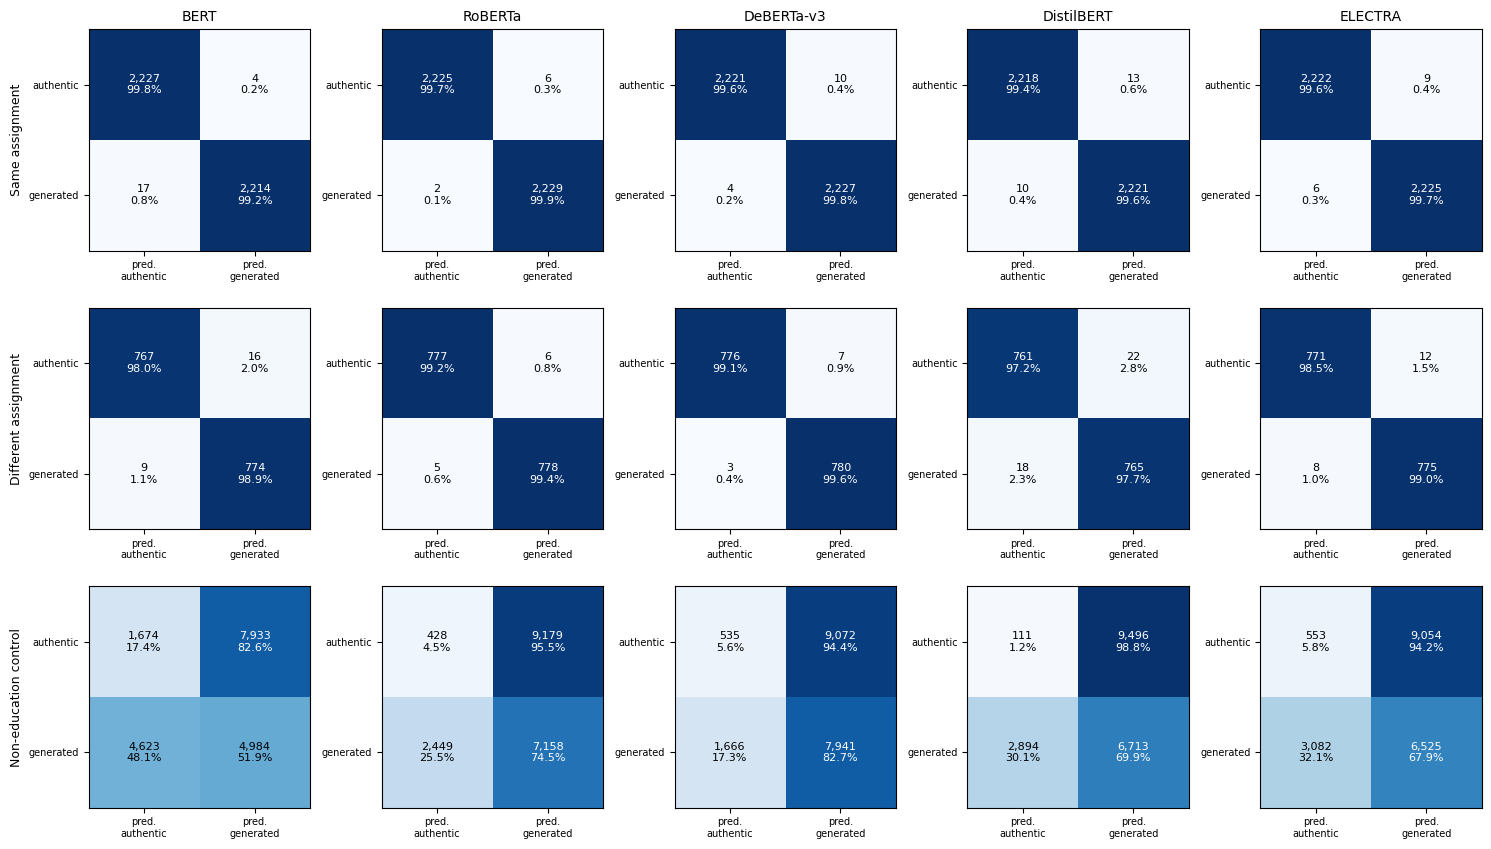

wrote fig_cm.png / .pdf


In [30]:
# --- ensure plotting deps (safe to run standalone) ---
import os
import matplotlib
import matplotlib.pyplot as plt
try:
    RESULTS
except NameError:
    REPO = os.path.abspath('..')
    RESULTS = os.path.join(REPO, 'results')
    PREDS = os.path.join(RESULTS, 'predictions')
FIGS = os.path.join(RESULTS, 'figures')
os.makedirs(FIGS, exist_ok=True)

# ---------------------------------------------------------------- Fig: confusion matrices
# One row per condition/eval set, one column per detector. The generated
# row is the one to read: its left cell is generated work passed as authentic.
from sklearn.metrics import confusion_matrix

CM_PANELS = [('pooled', 'indist', 'Same assignment'),
             ('xprompt_p0to1', 'other_assignment', 'Different assignment'),
             ('pooled', 'hf_pile', 'Non-education control')]

avail = [(c, e, t) for c, e, t in CM_PANELS
         if any(os.path.exists(os.path.join(PREDS, 'preds_%s_%s_seed42_%s.csv' % (c, m, e)))
                for m in MODEL_ORDER)]

if not avail:
    print('no predictions yet - run the sweep (section 9) first')
else:
    fig, axes = plt.subplots(len(avail), len(MODEL_ORDER),
                             figsize=(3.0 * len(MODEL_ORDER), 2.9 * len(avail)),
                             squeeze=False)
    for r, (cond, es, title) in enumerate(avail):
        for k, m in enumerate(MODEL_ORDER):
            ax = axes[r][k]
            f = os.path.join(PREDS, 'preds_%s_%s_seed42_%s.csv' % (cond, m, es))
            if not os.path.exists(f):
                ax.axis('off')
                continue
            d = pd.read_csv(f)
            cm = confusion_matrix(d['label'], d['pred'], labels=[0, 1])
            pct = cm / cm.sum(axis=1, keepdims=True) * 100
            ax.imshow(pct, cmap='Blues', vmin=0, vmax=100)
            for i in range(2):
                for j in range(2):
                    ax.text(j, i, '%s\n%.1f%%' % (format(cm[i, j], ','), pct[i, j]),
                            ha='center', va='center', fontsize=8,
                            color='white' if pct[i, j] > 55 else 'black')
            ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
            ax.set_xticklabels(['pred.\nauthentic', 'pred.\ngenerated'], fontsize=7)
            ax.set_yticklabels(['authentic', 'generated'], fontsize=7)
            if r == 0:
                ax.set_title(PRETTY[m], fontsize=10)
            if k == 0:
                ax.set_ylabel(title, fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS, 'fig_cm.png'), dpi=200, bbox_inches='tight')
    plt.savefig(os.path.join(FIGS, 'fig_cm.pdf'), bbox_inches='tight')
    plt.show()
    print('wrote fig_cm.png / .pdf')


## 12c. Explainability: what are the detectors reading?


The tokenizer you are loading from 'C:\Users\myreh_084hs1y\Documents\GRADE STUDY\Education Domain\models\xprompt_p0to1_deberta-v3_seed42' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


LIME xprompt_p0to1:   0%|          | 0/40 [00:00<?, ?it/s]

The tokenizer you are loading from 'C:\Users\myreh_084hs1y\Documents\GRADE STUDY\Education Domain\models\xprompt_p1to0_deberta-v3_seed42' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


LIME xprompt_p1to0:   0%|          | 0/40 [00:00<?, ?it/s]

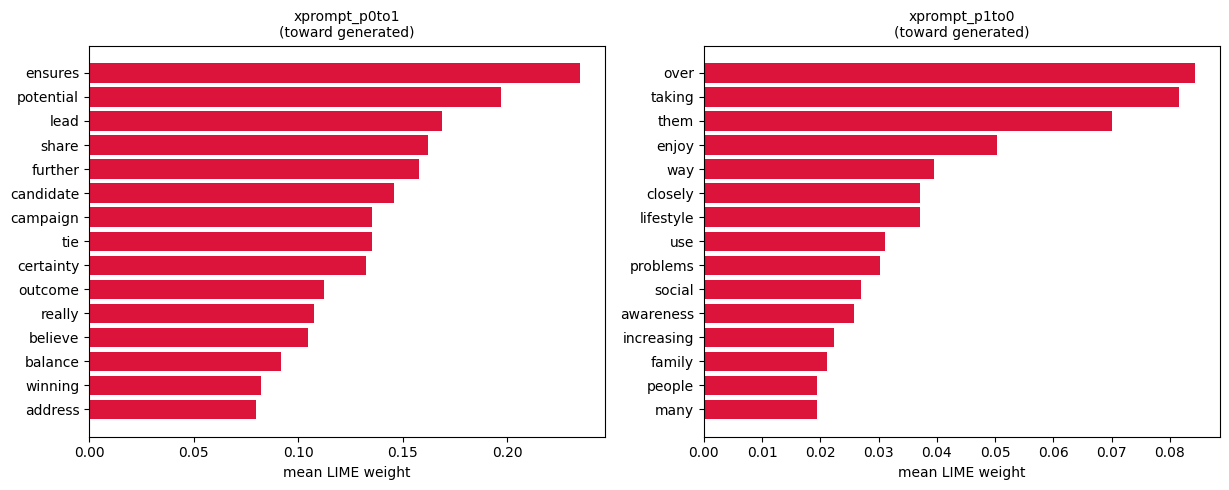


shared top tokens: ['way']
Jaccard overlap between assignments: 1.4%
(1 of 71 distinct tokens)

Low overlap  => detector keyed to assignment subject matter.
High overlap => evidence that survives a change of assignment.


In [31]:
# --- ensure plotting deps (safe to run standalone) ---
import os
import matplotlib
import matplotlib.pyplot as plt
try:
    RESULTS
except NameError:
    REPO = os.path.abspath('..')
    RESULTS = os.path.join(REPO, 'results')
    PREDS = os.path.join(RESULTS, 'predictions')
FIGS = os.path.join(RESULTS, 'figures')
os.makedirs(FIGS, exist_ok=True)

# ---------------------------------------------------------------- Fig: LIME attributions
# Does a detector key on the SUBJECT of the assignment, or on something
# about generated writing that survives a change of assignment?
# Explains correctly-classified essays under each cross-assignment condition
# and compares the top tokens between them.
#
# COST: LIME needs `num_samples` forward passes per explained document.
# N_EXPLAIN=40 at num_samples=500 is ~20k forward passes per condition.
# Reduce N_EXPLAIN if this is too slow.
try:
    from lime.lime_text import LimeTextExplainer
    HAVE_LIME = True
except ImportError:
    HAVE_LIME = False
    print('LIME not installed. Run:  pip install lime')

N_EXPLAIN = 40
NUM_SAMPLES = 500
LIME_MODEL = 'deberta-v3'      # explain one detector; change to compare

_STOPWORDS = ("a an the and or but if while of to in on at by for with from as is are "
              "was were be been being it its this that these those there here we our "
              "you your they their he she his her not no than then so such can could "
              "would should may might will just also very more most other some any "
              "each which who whom what when where how why do does did done have has "
              "had i me my")
STOP = set(_STOPWORDS.split())


def _predict_proba_factory(model, tok):
    def fn(texts):
        out = []
        for i in range(0, len(texts), 16):
            enc = encode(tok, texts[i:i + 16], CONFIG['max_len'])
            with torch.no_grad():
                out.append(torch.softmax(model(**enc).logits, 1).cpu().numpy())
        return np.vstack(out)
    return fn


if HAVE_LIME:
    explainer = LimeTextExplainer(class_names=['authentic', 'generated'])
    rows = []
    for cond, es in [('xprompt_p0to1', 'other_assignment'),
                     ('xprompt_p1to0', 'other_assignment')]:
        cd = ckpt_dir('%s_%s' % (cond, LIME_MODEL), 42)
        pf = os.path.join(PREDS, 'preds_%s_%s_seed42_%s.csv' % (cond, LIME_MODEL, es))
        if not (has_ckpt(cd) and os.path.exists(pf)):
            print('[skip] %s: needs checkpoint + predictions' % cond)
            continue
        tok = AutoTokenizer.from_pretrained(cd)
        model = AutoModelForSequenceClassification.from_pretrained(cd).to(DEVICE).eval()
        fn = _predict_proba_factory(model, tok)

        test_df = CONDITIONS[cond]['evals'][es].reset_index(drop=True)
        preds = pd.read_csv(pf)
        correct = preds.index[preds['label'] == preds['pred']]
        sample = pd.Series(list(correct)).sample(min(N_EXPLAIN, len(correct)),
                                                 random_state=42)
        for idx in tqdm(sample, desc='LIME %s' % cond):
            txt = str(test_df.loc[idx, 'text'])[:2000]
            exp = explainer.explain_instance(txt, fn, num_features=12,
                                             num_samples=NUM_SAMPLES, labels=(1,))
            for tokn, w in exp.as_list(label=1):
                t = tokn.lower().strip()
                if t and t not in STOP and t.isalpha() and len(t) > 2:
                    rows.append({'condition': cond, 'token': t, 'weight': w})
        del model, tok
        gc.collect()
        torch.cuda.empty_cache()

    if rows:
        lime_df = pd.DataFrame(rows)
        lime_df.to_csv(os.path.join(RESULTS, 'lime_tokens.csv'), index=False)
        top = (lime_df.groupby(['condition', 'token'])['weight']
               .agg(['mean', 'count']).reset_index())
        top = top[top['count'] >= 2].sort_values('mean', ascending=False)

        conds = top['condition'].unique().tolist()
        fig, axes = plt.subplots(1, len(conds), figsize=(6.2 * len(conds), 5),
                                 squeeze=False)
        for ax, cond in zip(axes[0], conds):
            sub = top[top['condition'] == cond].head(15).iloc[::-1]
            ax.barh(sub['token'], sub['mean'],
                    color=['crimson' if v > 0 else 'steelblue' for v in sub['mean']])
            ax.set_title('%s\n(toward generated)' % cond, fontsize=10)
            ax.set_xlabel('mean LIME weight')
        plt.tight_layout()
        plt.savefig(os.path.join(FIGS, 'fig_lime.png'), dpi=200, bbox_inches='tight')
        plt.savefig(os.path.join(FIGS, 'fig_lime.pdf'), bbox_inches='tight')
        plt.show()

        # the paper's question: do the two assignments share their evidence?
        if len(conds) == 2:
            a = set(top[top['condition'] == conds[0]].head(40)['token'])
            b = set(top[top['condition'] == conds[1]].head(40)['token'])
            jac = len(a & b) / max(len(a | b), 1)
            print('\nshared top tokens:', sorted(a & b))
            print('Jaccard overlap between assignments: %.1f%%' % (100 * jac))
            print('(%d of %d distinct tokens)' % (len(a & b), len(a | b)))
            print('\nLow overlap  => detector keyed to assignment subject matter.')
            print('High overlap => evidence that survives a change of assignment.')


---
### Outputs

* `results/table_results.tex` — main table, paste into §5.3
* `results/table_gap.tex` — generalization-gap table
* `results/generalization_gap.csv`, `detector_vs_baseline.csv`
* `results/figures/fig_roc.*`, `fig_gap.*`

Then update §5.3, §6 and the abstract with the printed macro values, and
re-check the word count with `python scripts/audit/wc.py`.